Import Libraries

In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

# choose GPU
import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated


In [2]:
n_gpu = len(jax.devices())
jax.devices()

E0523 13:14:54.512483  537441 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0523 13:14:54.521842  537316 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


[CudaDevice(id=0)]

In [3]:
# For Google Collab
# DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/data/"

# For PC
DATA_DIR = Path.cwd().parent.parent.parent / "data"

In [4]:
DATA_FILE = DATA_DIR / "data_T20_S30_G50.dat"

dat = np.loadtxt(DATA_FILE, skiprows=1, delimiter=',') # data on CPU
print (dat.shape)

# swap header for non reduced dataset as it was not labelled properly
if DATA_FILE == DATA_DIR / "data_T20_S30_G50.dat":
    dat[:, [0, 1]] = dat[:, [1, 0]]

# crop to focus on area of interest in the grid
# dat = dat[(dat[:,1] > 150) & (dat[:,1] < 350)] # selects all rows where the y-coordinate falls strictly between 150 and 350

# Calculate dimensions
nx = len(np.unique(dat[:, 0])) # take every row in x col 
ny = len(np.unique(dat[:, 1])) # take every row in y col

print(dat.shape)
print(f"Grid dimensions: nx={nx}, ny={ny}")
print(np.unique(dat[:,0]).shape, np.unique(dat[:,1]).shape) # unique coordinate values along each individual axis

x_l, x_u, y_l, y_u = np.unique(dat[:,0]).min(), np.unique(dat[:,0]).max(), np.unique(dat[:,1]).min(), np.unique(dat[:,1]).max()
ext = [x_l, x_u, y_l, y_u] # plot boundary
print(ext)

(491520, 4)
(491520, 4)
Grid dimensions: nx=960, ny=512
(960,) (512,)
[np.float64(0.5), np.float64(959.5), np.float64(0.5), np.float64(511.5)]


Text(0.5, 1.0, 'Solution')

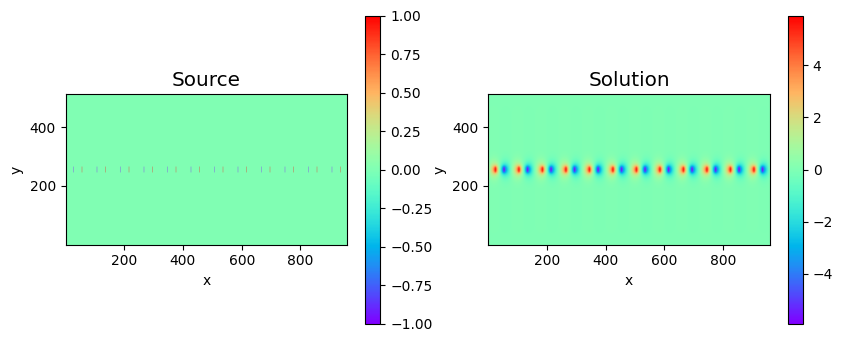

In [5]:
"""
Plot the system with boundaries as the perimeter of the plot
"""
# Source
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1,2,1)
s_plot = dat[:,2].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Source', fontsize='x-large')

# Solution
ax1 = fig.add_subplot(1,2,2)
s_plot = dat[:,3].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Solution', fontsize='x-large')

In [6]:
dat = jnp.array(dat) # data now on GPU
x, y, s, u_sim = dat[:,0].reshape(-1, 1), dat[:,1].reshape(-1, 1), dat[:,2].reshape(-1, 1), dat[:,3].reshape(-1, 1)

# Neumann Boundaries (Top and Bottom edges)
bc_n = ((y == y_l) | (y == y_u)).flatten()
print('Neumann BC: #sample = %d'%bc_n.sum())

# Boundary Conditions (bc), Periodic upper (pu) and Periodic  lower (pl)
bc_pl, bc_pu = ((x == x_l)).flatten(), ((x == x_u)).flatten()
print('Periodic BC: #sample = %d %d'%(bc_pl.sum(), bc_pu.sum()))

# bc_d = ((y == y_l) | (y == y_u) | (x == x_l) | (x == x_u)).flatten()
# print ('Dirichlet BC: #sample = %d'%bc_d.sum())

# Boundary points for mini-batching
x_n, y_n = x[bc_n], y[bc_n]
x_pl, y_pl = x[bc_pl], y[bc_pl]
x_pu, y_pu = x[bc_pu], y[bc_pu]

Neumann BC: #sample = 1920
Periodic BC: #sample = 512 512


FrPINN

In [7]:
# construct randomization B-PINN for linear/nonlinear ODE/PDEs
@jit
def get_f(x, y, weights):
    # Normalize x and y to range [-1, 1] based on grid boundaries
    x_norm = 2.0 * (x - x_l) / (x_u - x_l) - 1.0
    y_norm = 2.0 * (y - y_l) / (y_u - y_l) - 1.0
    
    h1 = x_norm * weights[0] + y_norm * weights[1] + weights[2]
    h2 = x_norm * weights[3] + y_norm * weights[4] + weights[5]
    h3 = x_norm * weights[6] + y_norm * weights[7] + weights[8]
    h4 = x_norm * weights[9] + y_norm * weights[10] + weights[11]
    h5 = x_norm * weights[12] + y_norm * weights[13] + weights[14]
    h6 = x_norm * weights[15] + y_norm * weights[16] + weights[17]

    f = jnp.hstack([jnp.sin(h1), jnp.sin(1*jnp.pi*h1), jnp.sin(2*jnp.pi*h1), nn.softplus(h2), jnp.tanh(h3),
                    jnp.sin(h4), jnp.sin(1*jnp.pi*h4), jnp.sin(2*jnp.pi*h4), nn.softplus(h5), jnp.tanh(h6)])
    return f

# obtain f_dir
def get_f_dir(get_f, x, y, weights):
    f_x, f_y = jacfwd(get_f)(x, y, weights), jacfwd(get_f, argnums=1)(x, y, weights)
    f_xx, f_yy = jacfwd(jacfwd(get_f))(x, y, weights), jacfwd(jacfwd(get_f, argnums=1), argnums=1)(x, y, weights)
    return f_x, f_y, f_xx, f_yy

f_vmap = vmap(get_f, in_axes=(0, 0, None))
f_dir_vmap = vmap(get_f_dir, in_axes=(None, 0, 0, None))

In [8]:
# no. of neurons
n_node = 150

# generate weight & bias distribution
seed = 0
key, rng = random.split(random.PRNGKey(seed))
key, rng = random.split(rng)
weights_n = random.truncated_normal(key, shape=(n_node, 9), lower=-1, upper=1) # sampled from normal distribution
key, rng = random.split(rng)
weights_u = random.uniform(key, (n_node, 9), minval=-1, maxval=1) # sampled from uniform distribution

# regularization
lamb = 1e-4

In [9]:
# Pre-train hyper-parameters for nonlinear hidden layer weights

param = jnp.array([ 10.09822957,  -3.87555686, -16.929685  ,  -2.77833317,
                   -15.22937101, -17.93026106,   0.75740902,  -1.08731573,
                   -15.22055726,   0.20566555,   2.09818805,   1.31966254,
                    41.06236758, -24.7403773 , -67.06658613,   1.87400817,
                     0.53709715,  12.50666705, -12.6852006 , -13.75918575,
                    23.12318144, -13.35527196,   7.92822574,  -1.26146055,
                   -26.1894822 ,  -0.72503231,   0.09145113,  -0.32225884,
                     3.04884214,  18.73283007, -11.30517284,   8.23196755,
                   -31.6906244 ,   1.65942281, -21.71534774,  13.22925764,
                     0.27084133])

In [ ]:
"""
Build Sub-matrices on CPU and perform Stratified Sampling
"""

@jit
def get_pde_chunk(x_c, y_c, weights):
    f_xx, f_yy = f_dir_vmap(get_f, x_c, y_c, weights)[2:]
    return (f_xx[:,:,0,0] + f_yy[:,:,0,0])

@jit
def get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights):
    f_y = f_dir_vmap(get_f, x_n, y_n, weights)[1][:,:,0]
    f_bc = f_vmap(x_pl, y_pl, weights) - f_vmap(x_pu, y_pu, weights)
    return f_y, f_bc

@jit
def kaczmarz_step(A_B, b_B, w, alpha): 
    block_size = A_B.shape[0]
    r = A_B @ w - b_B
    gram = A_B @ A_B.T + 1e-8 * jnp.eye(block_size)
    z = jnp.linalg.solve(gram, r)
    w_new = w - alpha * (A_B.T @ z)
    return w_new

In [ ]:
# Main execution function (No @jit here so we can manage memory loops)
def compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha):
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T
    reg = lamb * param[-1]

    chunk_size = 10000
    pde_list = []
    
    for i in range(0, x.shape[0], chunk_size):
        x_chunk = x[i:i+chunk_size]
        y_chunk = y[i:i+chunk_size]
        pde_chunk = get_pde_chunk(x_chunk, y_chunk, weights)
        
        pde_list.append(np.array(pde_chunk))

    pde_cpu = np.vstack(pde_list) / 100.
    pde_list.clear()

    fy_bc, f_bc = get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights)
    fy_bc_cpu = np.array(fy_bc)
    f_bc_cpu = np.array(f_bc)

    b_pde_cpu = np.array(s) / 100.

    m = pde_cpu.shape[1]
    lambda_I_cpu = np.sqrt(float(reg)) * np.eye(m)

    n_pde = pde_cpu.shape[0]
    n_nbc = fy_bc_cpu.shape[0]
    n_pbc = f_bc_cpu.shape[0]
    n_reg = lambda_I_cpu.shape[0]

    s_pde = int(block_size * 0.85)
    s_nbc = int(block_size * 0.05)
    s_pbc = int(block_size * 0.05)
    s_reg = block_size - s_pde - s_nbc - s_pbc 

    n_total = n_pde + n_nbc + n_pbc + n_reg
    
    import gc
    gc.collect()
    jax.clear_caches() 

    iters_per_epoch = n_total // block_size
    num_iterations = iters_per_epoch * epochs
    
    idx_pools = {
        'pde': {'indices': np.random.permutation(n_pde), 'ptr': 0, 'n': n_pde, 's': s_pde},
        'nbc': {'indices': np.random.permutation(n_nbc), 'ptr': 0, 'n': n_nbc, 's': s_nbc},
        'pbc': {'indices': np.random.permutation(n_pbc), 'ptr': 0, 'n': n_pbc, 's': s_pbc},
        'reg': {'indices': np.random.permutation(n_reg), 'ptr': 0, 'n': n_reg, 's': s_reg}
    }

    def sample_pool(pool_name):
        pool = idx_pools[pool_name]
        start = pool['ptr']
        end = start + pool['s']
        
        if pool['s'] > pool['n']:
            return np.random.choice(pool['n'], size=pool['s'], replace=True)
            
        if end > pool['n']:
            pool['indices'] = np.random.permutation(pool['n'])
            start = 0
            end = pool['s']
            
        pool['ptr'] = end
        return pool['indices'][start:end]
    
    w = jnp.zeros((m, 1))
    
    for i in tqdm(range(num_iterations), desc=f"Training {epochs} Epochs (Cyclic Shufflers)", unit="steps", miniters=500, maxinterval=jnp.inf):
        
        idx_pde = sample_pool('pde')
        idx_nbc = sample_pool('nbc')
        idx_pbc = sample_pool('pbc')
        idx_reg = sample_pool('reg')

        A_B_cpu = np.vstack([
            pde_cpu[idx_pde, :],
            fy_bc_cpu[idx_nbc, :],
            f_bc_cpu[idx_pbc, :],
            lambda_I_cpu[idx_reg, :]
        ])
        
        b_B_cpu = np.vstack([
            b_pde_cpu[idx_pde],
            np.zeros((s_nbc, 1)),
            np.zeros((s_pbc, 1)),
            np.zeros((s_reg, 1))
        ])
        
        A_B = jnp.array(A_B_cpu)
        b_B = jnp.array(b_B_cpu)
        
        current_epoch = i // iters_per_epoch
        decay_steps = current_epoch // 150 
        decayed_alpha = alpha * (0.5 ** decay_steps)
        
        w = kaczmarz_step(A_B, b_B, w, decayed_alpha)
        
        if i % 100 == 0:
            w.block_until_ready()
            
    w.block_until_ready() 
    
    del pde_cpu, fy_bc_cpu, f_bc_cpu, lambda_I_cpu
    
    chunk_size = 10000
    u_list = []
    
    for i in range(0, x.shape[0], chunk_size):
        x_c = x[i:i+chunk_size]
        y_c = y[i:i+chunk_size]
        
        f_chunk = f_vmap(x_c, y_c, weights)
        
        u_chunk = f_chunk @ w
        u_chunk.block_until_ready()
        u_list.append(u_chunk)

    u = jnp.vstack(u_list)
    u_list.clear() 
    
    mse = jnp.mean((u_sim - u)**2)  
    mae = jnp.mean(jnp.abs(u_sim - u))
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    
    return u, mse, mae, rl2

Training 500 Epochs (Cyclic Shufflers):   0%|          | 0/247500 [00:00<?, ?steps/s]

MSE = 6.86e-01  MAE = 5.88e-01  RL2 = 1.31e+00


Text(0.5, 1.0, 'PINN')

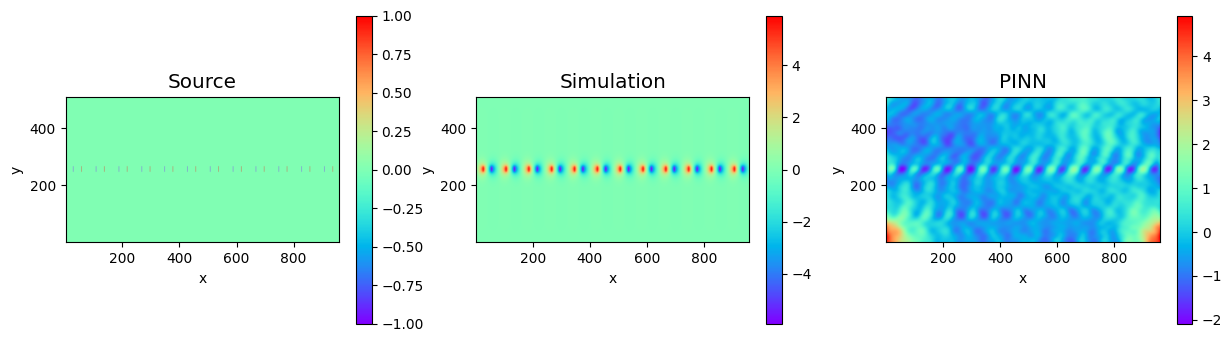

In [12]:
# solve problem
epochs = 500
block_size = 1000 # set based on GPU VRAM limits
alpha = 0.001 # learning rate

key, rng = random.split(rng)
u, mse, mae, rl2 = compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha) # hard coded for block = 500
print('MSE = %.2e  MAE = %.2e  RL2 = %.2e'%(mse, mae, rl2));

# plot solution
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1,3,1)
s_plot = s.reshape(nx, ny).T 
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Source', fontsize='x-large')
ax1 = fig.add_subplot(1,3,2)
s_plot = u_sim.reshape(nx, ny).T 
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Simulation', fontsize='x-large')
ax1 = fig.add_subplot(1,3,3)
s_plot = u.reshape(nx, ny).T  
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN', fontsize='x-large')

Time the run

In [13]:
# _ = compute_ls_ntask_kazmarz_batched(param, key)

In [14]:
#%%timeit -n 10 -r 2
#u, mse, rl2, mae = compute_ls_ntask_kazmarz_batched(param, key)
#u.block_until_ready()